# Restaurant Ratings Level 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
df=pd.read_excel("Dataset.xlsx")

In [5]:
rating_count = df['Aggregate rating'].value_counts().sort_index()
print(rating_count)

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


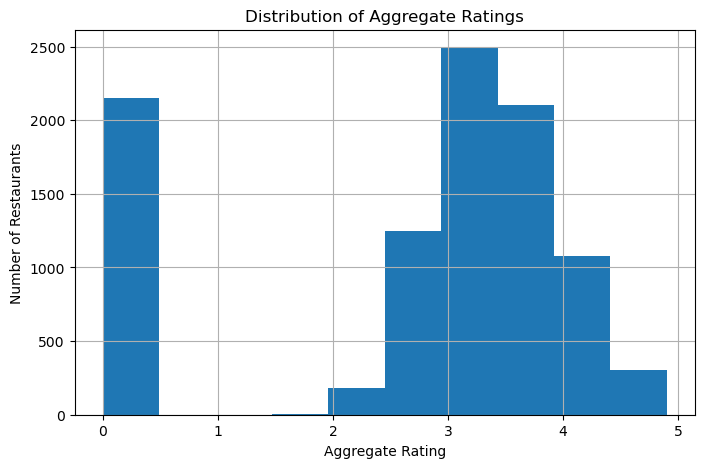

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Aggregate rating'], bins=10)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.grid(True)

plt.show()

In [8]:
most_common_rating = df['Aggregate rating'].mode()[0]
print("Most Common Rating:", most_common_rating)

Most Common Rating: 0.0


In [10]:
bins =[0, 1, 2, 3, 4, 5]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5']
df['Rating Range'] = pd.cut(df['Aggregate rating'],
                            bins=bins,
                            labels=labels,
                            include_lowest=True)
rating_range = df['Rating Range'].value_counts().sort_index()
print(rating_range)

Rating Range
0-1    2148
1-2      10
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64


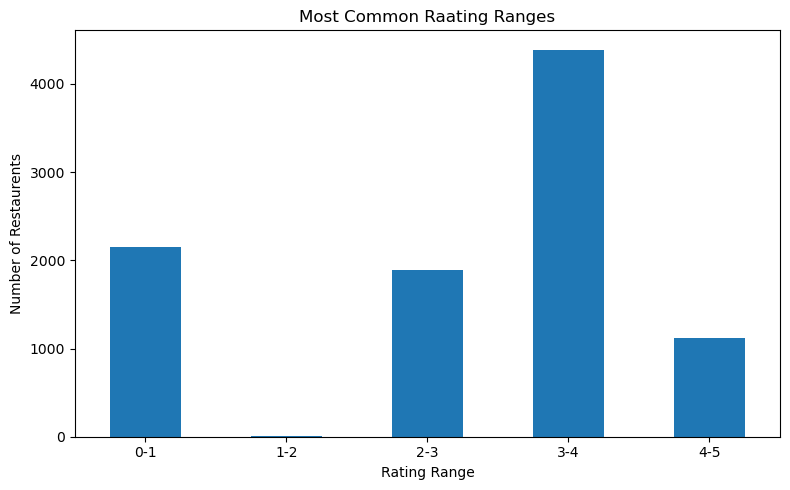

In [12]:
plt.figure(figsize=(8,5))
rating_range.plot(kind='bar')
plt.title("Most Common Raating Ranges")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
average_votes = df['Votes'].mean()
print("Average Number of Votes:", average_votes)

Average Number of Votes: 156.909747670401


In [19]:
top_votes = df[['Restaurant Name', 'Votes']].sort_values(by='Votes', ascending=False).head(10)

print(top_votes)

                Restaurant Name  Votes
728                        Toit  10934
735                    Truffles   9667
3994           Hauz Khas Social   7931
2412                  Peter Cat   7574
739   AB's - Absolute Barbecues   6907
2414            Barbeque Nation   5966
743                 Big Brewsky   5705
2307  AB's - Absolute Barbecues   5434
736             The Black Pearl   5385
2411                      BarBQ   5288


# Task 2 Cuisine Combination

In [20]:
cuisine_combinations = df['Cuisines'].value_counts().head(10)
print(cuisine_combinations)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


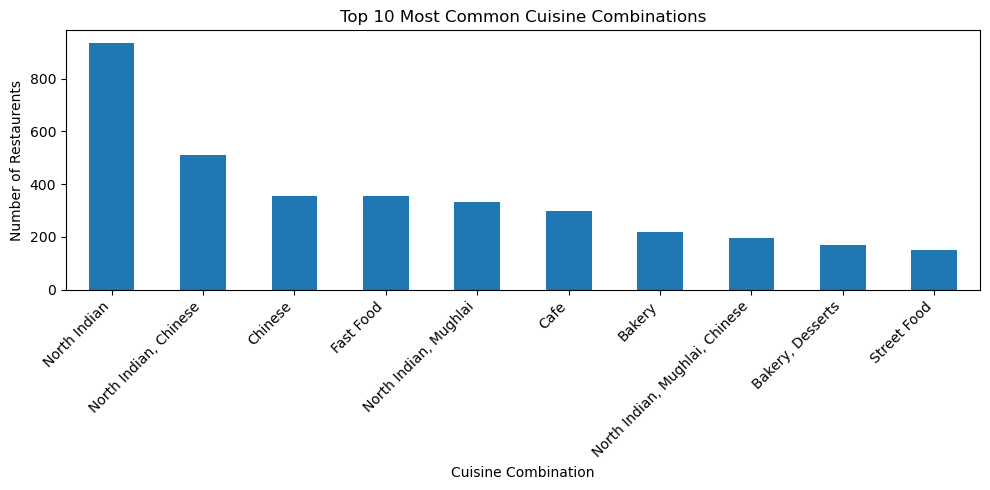

In [21]:
plt.figure(figsize=(10,5))
cuisine_combinations.plot(kind='bar')
plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of Restaurents")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
average_rating = df.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)
print(average_rating.head(10))

Cuisines
Italian, Deli               4.9
Hawaiian, Seafood           4.9
American, Sandwich, Tea     4.9
Continental, Indian         4.9
European, Asian, Indian     4.9
European, Contemporary      4.9
European, German            4.9
BBQ, Breakfast, Southern    4.9
American, Coffee and Tea    4.9
Sunda, Indonesian           4.9
Name: Aggregate rating, dtype: float64


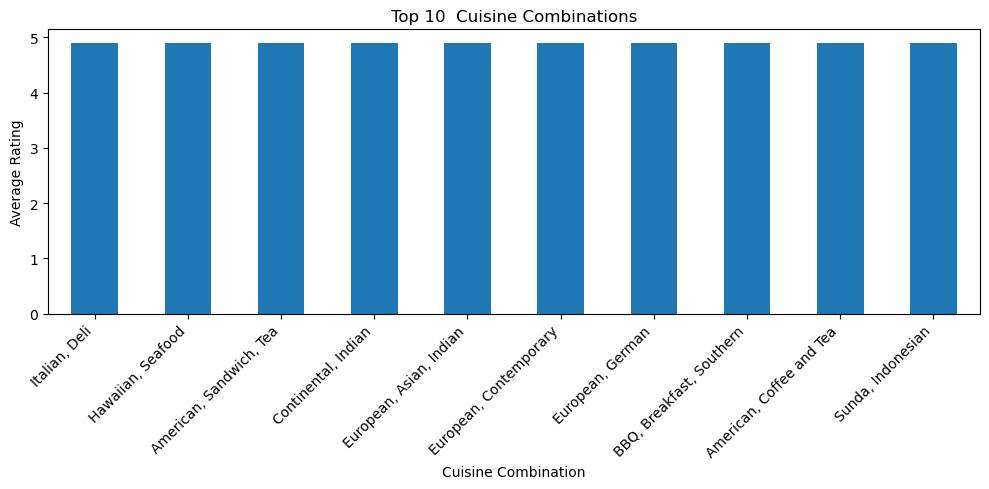

In [23]:
plt.figure(figsize=(10,5))
average_rating.head(10).plot(kind='bar')
plt.title("Top 10  Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Task 3 Geographic Analysis

In [29]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/2 [branca]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [32]:
import folium

restaurant_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=5
)

restaurant_map

In [33]:
restaurant_map

In [36]:
import folium

restaurant_map = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=5
)

restaurant_map

In [37]:
restaurant_map.save("Restaurant_location_Map.html")
print("Map saved successfully!")

Map saved successfully!


# Task 4 Restaurant Chains

In [39]:
print(df.columns.tolist())

['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Rating Range']


In [40]:
chain_counts = df['Restaurant Name'].value_counts()

restaurant_chains = chain_counts[chain_counts > 1]

print(restaurant_chains)

Restaurant Name
Cafe Coffee Day       83
Domino's Pizza        79
Subway                63
Green Chick Chop      51
McDonald's            48
                      ..
Town Hall              2
Halki Aanch            2
Snack Junction         2
Delhi Biryani Hut      2
Beliram Degchiwala     2
Name: count, Length: 734, dtype: int64


In [42]:
top_chains = restaurant_chains.head(10)
print(top_chains)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64


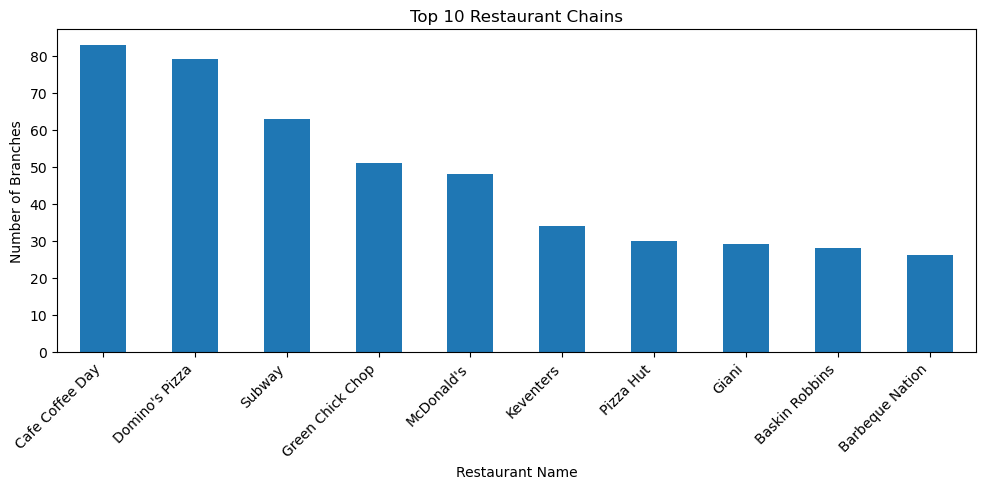

In [43]:
plt.figure(figsize=(10,5))
top_chains.plot(kind='bar')
plt.title("Top 10 Restaurant Chains")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Branches")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [46]:
chain_ratings = df.groupby('Restaurant Name')['Aggregate rating'].mean()

top_chain_ratings = chain_ratings.loc[top_chains.index]

print(top_chain_ratings)

Restaurant Name
Cafe Coffee Day     2.419277
Domino's Pizza      2.740506
Subway              2.907937
Green Chick Chop    2.672549
McDonald's          3.339583
Keventers           2.870588
Pizza Hut           3.320000
Giani               2.689655
Baskin Robbins      1.860714
Barbeque Nation     4.353846
Name: Aggregate rating, dtype: float64


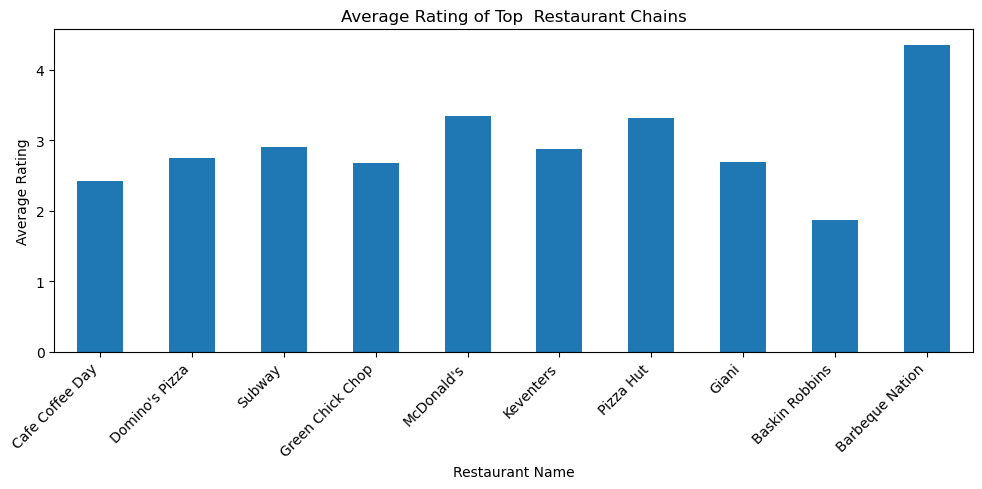

In [48]:
plt.figure(figsize=(10,5))
top_chain_ratings.plot(kind='bar')
plt.title("Average Rating of Top  Restaurant Chains")
plt.xlabel("Restaurant Name")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
chain_votes = df.groupby('Restaurant Name')['Votes'].mean()
top_chain_votes = chain_votes.loc[top_chains.index]
print(top_chain_votes)

Restaurant Name
Cafe Coffee Day       29.253012
Domino's Pizza        84.088608
Subway                97.206349
Green Chick Chop      18.901961
McDonald's           110.229167
Keventers             37.147059
Pizza Hut            165.366667
Giani                 29.448276
Baskin Robbins        15.285714
Barbeque Nation     1082.384615
Name: Votes, dtype: float64


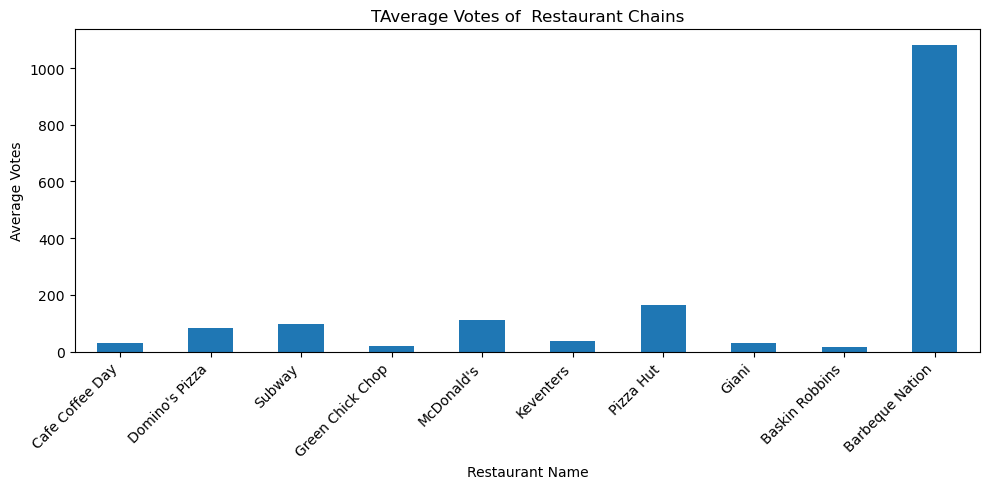

In [51]:
plt.figure(figsize=(10,5))
top_chain_votes.plot(kind='bar')
plt.title("TAverage Votes of  Restaurant Chains")
plt.xlabel("Restaurant Name")
plt.ylabel("Average Votes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()